In [27]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr

from langchain_openai import ChatOpenAI

import json
import random
from operator import add

In [28]:
load_dotenv(override=True)

True

In [29]:
class WorkerAnswer(TypedDict):
    model: str
    response: str


class AnonymizedAnswer(TypedDict):
    label: str          # e.g. "Response A"
    model: str          # underlying model name (private)
    response: str       # answer text (public)


class RankingResponse(TypedDict):
    evaluator: str              # model doing the evaluation
    ranking: list[str]          # ordered labels, e.g. ["Response B", "Response A"]
    justification: str          # evaluator critique text (without the final ranking footer)
    ranking_text: str          # full evaluator output (for chairman context)


class AggregateRow(TypedDict):
    model: str
    average_rank: float
    rankings_count: int


class AggregateResponse(TypedDict):
    answer: str  # final answer
    justification: str  # justification for the answer


def merge_metadata(left: dict, right: dict) -> dict:
    """Merge reducer for LangGraph state metadata."""
    merged = dict(left or {})
    merged.update(right or {})
    return merged

class State(TypedDict):
    user_query: str
    worker_answers: Annotated[list[WorkerAnswer], add]
    anonymized_answers: list[AnonymizedAnswer]
    peer_rankings: Annotated[list[RankingResponse], add]
    aggregate_rankings: list[AggregateRow]
    metadata: Annotated[dict, merge_metadata]
    final_result: AggregateResponse

In [30]:
council_models = [
    "gpt-4o-mini",
    "gpt-3.5-turbo",
    "gpt-4.1-nano"
]
chair_model = "gpt-4o-mini"

In [31]:
def make_worker_node(model_name: str):
    """Create a worker node bound to a specific model."""
    llm = ChatOpenAI(model=model_name)

    def worker_node(state: State) -> State:
        # Stage-1 worker: keep Karpathy-style simplicity (no extra system prompt).
        messages = [
            {"role": "user", "content": state["user_query"]},
        ]

        try:
            reply = llm.invoke(messages)
            text = reply.content if isinstance(reply.content, str) else str(reply.content)
        except Exception:
            # If the model call fails, contribute no answer.
            return {}

        new_answer: WorkerAnswer = {
            "model": model_name,
            "response": text.strip(),
        }

        # `worker_answers` is an Annotated list, so multiple worker nodes
        # can safely contribute in the same step.
        return {
            "worker_answers": [new_answer]
        }

    return worker_node

In [32]:
def make_ranking_node(evaluator_name: str):
    """Create a ranking node for a specific evaluator assistant.

    This mimics Karpathy's llm-council stage-2 protocol:
    - each evaluator critiques each anonymized response
    - then provides a final ranking footer that we parse with regex
    """

    import re

    llm = ChatOpenAI(model=evaluator_name, temperature=0.0)

    def parse_ranking_footer(text: str, valid_labels_order: list[str]) -> list[str]:
        valid_labels = set(valid_labels_order)
        m = re.search(r"FINAL_RANKING\s*:\s*", text, flags=re.IGNORECASE)
        if not m:
            return []

        # Parse everything after FINAL_RANKING: (numbered list or freeform).
        block = text[m.end() :].strip()
        raw_letters = re.findall(r"Response\s+([A-Z])", block, flags=re.IGNORECASE)

        normed: list[str] = []
        seen: set[str] = set()
        for letter in raw_letters:
            norm = f"Response {letter.upper()}"
            if norm in valid_labels and norm not in seen:
                normed.append(norm)
                seen.add(norm)

        if not normed:
            return []

        # If the evaluator only mentioned a tiny subset of labels,
        # don't fabricate a complete ranking.
        required_extracted = max(2, (len(valid_labels_order) + 1) // 2)
        if len(normed) < required_extracted:
            return []

        # Repair incomplete rankings by appending missing labels in order.
        for lbl in valid_labels_order:
            if lbl not in seen:
                normed.append(lbl)

        return normed

    def ranking_node(state: State) -> State:
        answers = state.get("anonymized_answers", [])
        if len(answers) < 2:
            return {}

        valid_labels_order = [a["label"] for a in answers]
        responses_text = "\n\n".join(
            f"{a['label']}:\n{a['response']}" for a in answers
        )
        example_ranking = "\n".join(
            f"{i + 1}. {lbl}" for i, lbl in enumerate(valid_labels_order)
        )

        system_message = (
            f"You are evaluating responses as model '{evaluator_name}'.\n\n"
            "You will see several anonymized responses labeled 'Response A',\n"
            "'Response B', etc.\n\n"
            "Task:\n"
            "1. First, evaluate each response individually.\n"
            "   For each response, write 2-4 sentences: what it does well and what it does poorly.\n"
            "2. Then, at the very end, rank the responses from best to worst.\n\n"
            "CRITICAL OUTPUT FORMAT:\n"
            "At the very end of your response, output this block exactly:\n"
            "FINAL_RANKING:\n"
            f"{example_ranking}\n"
            "The numbered list must include ALL responses exactly once.\n"
            "No other text after the last numbered line.\n"
        )

        user_message = (
            "Original question:\n"
            f"{state['user_query']}\n\n"
            "Anonymized responses:\n\n"
            f"{responses_text}\n\n"
        )

        messages = [
            {"role": "system", "content": system_message},
            {"role": "user", "content": user_message},
        ]

        try:
            reply = llm.invoke(messages)
            text = reply.content if isinstance(reply.content, str) else str(reply.content)
        except Exception:
            # If this evaluator fails, just contribute no ranking.
            return {}

        text = text.strip()
        ranking = parse_ranking_footer(text, valid_labels_order)
        if len(ranking) < 2:
            return {}

        footer_match = re.search(r"FINAL_RANKING\s*:\s*", text, flags=re.IGNORECASE)
        justification = text[: footer_match.start()].strip() if footer_match else text

        ranking_response: RankingResponse = {
            "evaluator": evaluator_name,
            "ranking": ranking,
            "justification": justification,
            "ranking_text": text,
        }

        # `peer_rankings` is an Annotated list, so multiple ranking nodes
        # can safely contribute in the same step.
        return {
            "peer_rankings": [ranking_response]
        }

    return ranking_node

In [33]:
from typing import Any, Dict, List
from collections import defaultdict


def collect_and_anonymize_node(state: State) -> State:
    """Collect all worker answers, filter/clean, shuffle, and assign labels.

    Produces `anonymized_answers` with stable labels like "Response A".
    """
    answers = [
        a for a in state.get("worker_answers", [])
        if isinstance(a.get("response"), str) and a["response"].strip()
    ]

    metadata = dict(state.get("metadata", {}) or {})
    shuffle_seed = metadata.get("shuffle_seed")
    if shuffle_seed is None:
        shuffle_seed = random.randint(0, 2**32 - 1)
        metadata["shuffle_seed"] = shuffle_seed
    rng = random.Random(shuffle_seed)
    rng.shuffle(answers)

    anonymized: List[AnonymizedAnswer] = []
    for i, item in enumerate(answers):
        label = f"Response {chr(65 + i)}"
        anonymized.append(
            {
                "label": label,
                "model": item["model"],
                "response": item["response"],
            }
        )

    metadata["label_to_model"] = {a["label"]: a["model"] for a in anonymized}
    return {"anonymized_answers": anonymized, "metadata": metadata}

In [34]:
def calculate_aggregate_rankings(state: State) -> List[AggregateRow]:
    """Calculate aggregate rankings across all models using label-based rankings.

    For each model, compute the average position it received across
    all evaluators' `ranking` lists. Lower average rank is better.
    """
    anonymized = state.get("anonymized_answers", [])
    rankings = state.get("peer_rankings", [])

    if len(anonymized) < 2 or not rankings:
        return []

    label_to_model: Dict[str, str] = {a["label"]: a["model"] for a in anonymized}

    model_positions: Dict[str, List[int]] = defaultdict(list)

    for r in rankings:
        evaluator = r["evaluator"]
        for position, label in enumerate(r["ranking"], start=1):
            model = label_to_model.get(label)
            if not model or model == evaluator:
                # Skip unknown labels and exclude self-votes.
                continue
            model_positions[model].append(position)

    aggregate: List[AggregateRow] = []
    for model, positions in model_positions.items():
        if not positions:
            continue
        avg_rank = sum(positions) / len(positions)
        aggregate.append(
            {
                "model": model,
                "average_rank": round(avg_rank, 2),
                "rankings_count": len(positions),
            }
        )

    aggregate.sort(key=lambda x: x["average_rank"])  # lower is better
    return aggregate

In [35]:
def aggregate_calculations_node(state: State) -> State:
    """Compute aggregate peer rankings from label-based peer rankings.

    This node performs deterministic calculations only and does NOT
    choose the final answer.
    """
    aggregate_rankings = calculate_aggregate_rankings(state)
    return {"aggregate_rankings": aggregate_rankings}

In [36]:
def chairman_node(state: State) -> State:
    """Final chairman that synthesizes the best final answer.

    Karpathy-like stage-3 inputs:
    - original question
    - stage-1 worker answers with model names
    - stage-2 evaluator writeups with evaluator model names
    """

    structured_llm = ChatOpenAI(model=chair_model, temperature=0.0).with_structured_output(AggregateResponse)

    worker_answers = state.get("worker_answers", [])
    peer_rankings = state.get("peer_rankings", [])
    aggregate_rankings = state.get("aggregate_rankings", [])

    if not worker_answers:
        metadata = dict(state.get("metadata", {}) or {})
        metadata["chair_fallback_used"] = True
        metadata["chair_fallback_reason"] = "no_worker_answers"
        return {
            "final_result": {
                "answer": "I don't know.",
                "justification": "No valid council answers were produced.",
            },
            "metadata": metadata,
        }

    model_index = {m: i for i, m in enumerate(council_models)}

    ordered_worker_answers = sorted(
        worker_answers,
        key=lambda wa: model_index.get(wa.get("model"), 10_000_000),
    )

    stage1_text = "\n\n".join(
        f"Model: {wa['model']}\nAnswer: {wa['response']}" for wa in ordered_worker_answers if wa.get("response")
    )

    ordered_peer_rankings = sorted(
        peer_rankings,
        key=lambda pr: model_index.get(pr.get("evaluator"), 10_000_000),
    )

    metadata = dict(state.get("metadata", {}) or {})
    metadata["worker_models_ordered"] = [wa.get("model") for wa in ordered_worker_answers if wa.get("model")]
    metadata["evaluator_models_ordered"] = [
        pr.get("evaluator") for pr in ordered_peer_rankings if pr.get("evaluator")
    ]
    successful_workers_set = {wa.get("model") for wa in ordered_worker_answers if wa.get("model")}
    metadata["worker_models_missing"] = [m for m in council_models if m not in successful_workers_set]
    successful_rankers_set = {pr.get("evaluator") for pr in ordered_peer_rankings if pr.get("evaluator")}
    metadata["ranker_models_missing"] = [m for m in council_models if m not in successful_rankers_set]
    metadata["peer_rankings_count"] = len(peer_rankings)
    metadata["aggregate_rankings_count"] = len(aggregate_rankings)

    stage2_text = "\n\n".join(
        f"Evaluator: {pr['evaluator']}\nRanking writeup:\n{pr.get('ranking_text', '')}" for pr in ordered_peer_rankings
    )

    context = {
        "question": state["user_query"],
        "stage1_text": stage1_text,
        "stage2_text": stage2_text,
    }

    system_message = (
        "You are the final impartial chair of an LLM council.\n\n"
        "You will be given:\n"
        "- the original question\n"
        "- stage 1: model answers (with model names)\n"
        "- stage 2: evaluator critiques + final ranking footer (with evaluator names)\n\n"
        "Synthesize the BEST possible final answer for the user.\n"
        "Do NOT mention internal labels or council provenance in the final answer."
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": json.dumps(context)},
    ]

    try:
        structured_response: AggregateResponse = structured_llm.invoke(messages)
        metadata["chair_fallback_used"] = False
        metadata["chair_fallback_reason"] = None
        return {"final_result": structured_response, "metadata": metadata}
    except Exception:
        # Fallback: pick the best available worker answer.
        metadata["chair_fallback_used"] = True
        metadata["chair_fallback_reason"] = "chair_structured_llm_exception"
        best_answer = ""
        if aggregate_rankings:
            best_model = aggregate_rankings[0]["model"]
            for wa in worker_answers:
                if wa.get("model") == best_model and wa.get("response"):
                    best_answer = wa["response"]
                    break

        if not best_answer:
            # Deterministic fallback: pick first non-empty response in council order.
            for wa in ordered_worker_answers:
                resp = (wa.get("response") or "").strip()
                if resp:
                    best_answer = resp
                    break

        if not best_answer:
            best_answer = "I don't know."

        return {
            "final_result": {
                "answer": best_answer,
                "justification": "Fallback: selected best available worker answer.",
            },
            "metadata": metadata,
        }

In [37]:
graph_builder = StateGraph(State)

# Worker nodes: each model produces an answer.
for model_name in council_models:
    worker_node_name = f"worker_{model_name}"
    graph_builder.add_node(worker_node_name, make_worker_node(model_name))
    graph_builder.add_edge(START, worker_node_name)

# Collection/anonymization node: collects all worker answers and assigns labels.
graph_builder.add_node("collect_and_anonymize", collect_and_anonymize_node)
for model_name in council_models:
    worker_node_name = f"worker_{model_name}"
    graph_builder.add_edge(worker_node_name, "collect_and_anonymize")

# Ranking nodes: one per assistant (peer evaluator), all see the same anonymized set.
for model_name in council_models:
    ranking_node_name = f"ranking_{model_name}"
    graph_builder.add_node(ranking_node_name, make_ranking_node(model_name))
    graph_builder.add_edge("collect_and_anonymize", ranking_node_name)

# Aggregate calculations node: compute stats only.
graph_builder.add_node("aggregate_calculations", aggregate_calculations_node)
for model_name in council_models:
    ranking_node_name = f"ranking_{model_name}"
    graph_builder.add_edge(ranking_node_name, "aggregate_calculations")

# Chairman node: final decision-maker.
graph_builder.add_node("chairman", chairman_node)
graph_builder.add_edge("aggregate_calculations", "chairman")
graph_builder.add_edge("chairman", END)

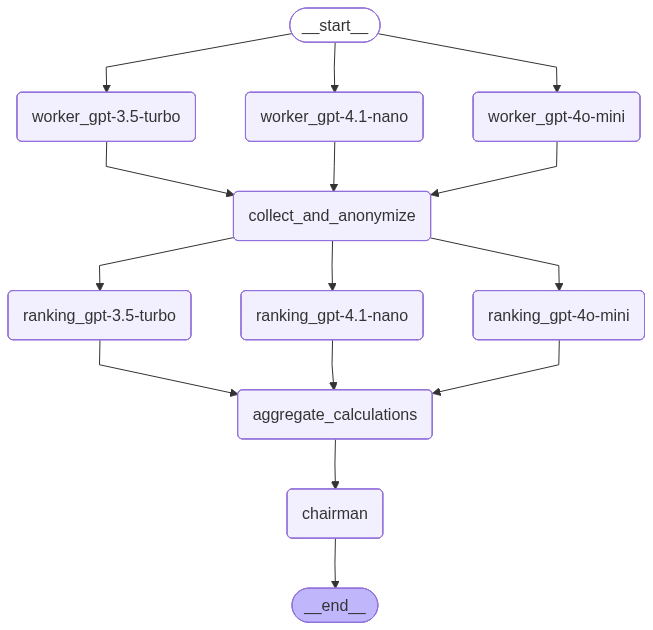

In [38]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
def chat(user_input: str, history):
    initial_state: State = {
        "user_query": user_input,
        "worker_answers": [],
        "anonymized_answers": [],
        "peer_rankings": [],
        "aggregate_rankings": [],
        "metadata": {},
        "final_result": {"answer": "", "justification": ""},
    }
    result: State = graph.invoke(initial_state)

    final = result["final_result"]
    answer_text = (final.get("answer", "") or "").strip()
    justification = (final.get("justification", "") or "").strip()

    if justification:
        return f"{answer_text}\n\n---\nJustification:\n{justification}".strip()

    return answer_text


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
